<a href="https://colab.research.google.com/github/rajeshtikaddar/Internship/blob/main/Network_Traffic_Investigation_using_Python_Day_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dataset**

In [15]:
import pandas as pd
network_data = {
  "Device": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"],
  "Packets": [120, 140, 150, 1800, 130, 160, 2200, 110, 145, 1900],
  "Protocol": ["TCP", "TCP", "UDP", "TCP", "UDP", "TCP", "TCP", "UDP", "TCP", "TCP"],
  "Connection_Duration": [12, 15, 18, 240, 14, 16, 300, 10, 13, 270]
}

df = pd.DataFrame(network_data)
df.head()

,Device,Packets,Protocol,Connection_Duration
0,A,120,TCP,12
1,B,140,TCP,15
2,C,150,UDP,18
3,D,1800,TCP,240
4,E,130,UDP,14


**Dataset Information**

In [4]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Device               10 non-null     object
 1   Packets              10 non-null     int64 
 2   Protocol             10 non-null     object
 3   Connection_Duration  10 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 452.0+ bytes


,Packets,Connection_Duration
count,10.000000,10.000000
mean,685.500000,90.800000
std,889.633039,124.484537
min,110.000000,10.000000
25%,132.500000,13.250000
50%,147.500000,15.500000
75%,1390.000000,184.500000
max,2200.000000,300.000000


**Calculate**

In [5]:
total_packets = df["Packets"].sum()
avg_packets = df["Packets"].mean()
max_packets = df["Packets"].max()

print("\nTotal Packets =", total_packets)
print("Average Packets =", avg_packets)
print("Maximum Packets =", max_packets)


Total Packets = 6855
Average Packets = 685.5
Maximum Packets = 2200


**Identify Devices generating abnormal traffic**

In [6]:
abnormal_devices = df[df["Packets"] > 1500]

print("\nDevices with Abnormal Traffic:")
print(abnormal_devices)


Devices with Abnormal Traffic:
  Device  Packets Protocol  Connection_Duration
3      D     1800      TCP                  240
6      G     2200      TCP                  300
9      J     1900      TCP                  270


**Create a new column "Risk_Level"**

In [7]:
def risk_level(packet):
  if packet < 500:
    return "Low"
  elif packet <= 1500:
    return "Medium"
  else:
    return "High"


df["Risk_Level"] = df["Packets"].apply(risk_level)

print("\nUpdated DataFrame:")
print(df)


Updated DataFrame:
  Device  Packets Protocol  Connection_Duration Risk_Level
0      A      120      TCP                   12        Low
1      B      140      TCP                   15        Low
2      C      150      UDP                   18        Low
3      D     1800      TCP                  240       High
4      E      130      UDP                   14        Low
5      F      160      TCP                   16        Low
6      G     2200      TCP                  300       High
7      H      110      UDP                   10        Low
8      I      145      TCP                   13        Low
9      J     1900      TCP                  270       High


**Count devices in each risk category**

In [8]:
risk_counts = df["Risk_Level"].value_counts()

print("\nRisk Category Counts:")
print(risk_counts)


Risk Category Counts:
Risk_Level
Low     7
High    3
Name: count, dtype: int64


**Create Bar Chart for Packet Counts**

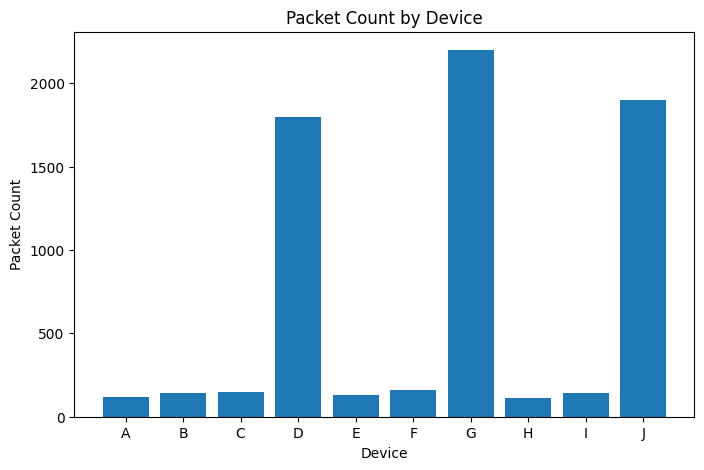

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(df["Device"], df["Packets"])
plt.xlabel("Device")
plt.ylabel("Packet Count")
plt.title("Packet Count by Device")
plt.show()

**Histogram for Traffic Distribution**

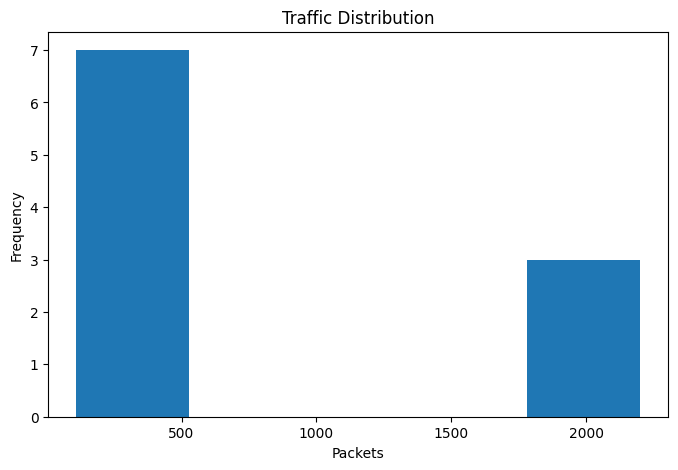

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df["Packets"], bins=5)
plt.xlabel("Packets")
plt.ylabel("Frequency")
plt.title("Traffic Distribution")
plt.show()

**Generate Network Threat Summary**

In [14]:
print("Total Devices :", len(df))
print("Total Packets :", total_packets)
print("Average Packets :", round(avg_packets,2))
print("Maximum Packets :", max_packets)

print("\nSuspicious Devices:")
# Re-filter df to get abnormal_devices, ensuring it includes the 'Risk_Level' column
abnormal_devices = df[df["Packets"] > 1500]
print(abnormal_devices[["Device","Packets","Risk_Level"]])

print("\nRisk Level Distribution:")
print(risk_counts)

print("\nNetwork Traffic Analysis Report :")
print("Devices D, G and J are generating unusually high traffic.")
print("These devices are classified as HIGH risk.")
print("Most devices have LOW risk traffic levels.")
print("High traffic may indicate malware communication, botnet activity or data exfiltration.")

Total Devices : 10
Total Packets : 6855
Average Packets : 685.5
Maximum Packets : 2200

Suspicious Devices:
  Device  Packets Risk_Level
3      D     1800       High
6      G     2200       High
9      J     1900       High

Risk Level Distribution:
Risk_Level
Low     7
High    3
Name: count, dtype: int64

Network Traffic Analysis Report :
Devices D, G and J are generating unusually high traffic.
These devices are classified as HIGH risk.
Most devices have LOW risk traffic levels.
High traffic may indicate malware communication, botnet activity or data exfiltration.
